# Stochastic Gradient Descent (Descenso de graciente estocastico)

## Peso
Cuando conectamos dos nodos de una red neuronal, habra un valor asociado a esta conexion, que se le llamara **Peso**. Este **Peso** determina la importancia que hay entre esta conexion de neuronas, ya que recordemos que cuando creamos una red neuronal, es posible conectar nodos de capa a capa, pero tiene sentido que digamos que no todas las conexiones hacen lo mismo o valen lo mismo. 

Tambien tenemos el concepto de **Sesgo**, que son valores adicionales que se suman a la suma ponderada de las entradas que recibe una neurona. Podria decirse que se trata de una entrada constante adicional para una neurona. Su funcion es la activar la neuraona.

## La funcion de perdida

Ya hemos visto como diseñar una red neuroal, pero aun no hemos visto como hacerle aprender. Esta parte de como aprender le pertenece a la **Funcion de Perdida** (loss function). La funcion de perdida mide la disparidad entre el valor real y el predicho por el modelo que tenemos.

## The Optimizer (optimisador)

Aunque ya diseñaremos la red de neuronas y mediremos como aprendre para que aprenda bien, tambien deberemos darl una forma de otpimizarse asi mismo. La red en si contara con un algotimo de optimizacion usara por la familia de gradientes estocasticos.

In [2]:
import pandas as pd
red_wine = pd.read_csv("data/red-wine.csv")

In [3]:
# creamos los conjuntos de entrenamiento y de validacion
df_train = red_wine.sample(frac = 0.7, random_state = 0)
df_valid = red_wine.drop(df_train.index)
display(df_train.head(4))

# scalamos del 0 al 1 [0,1]
max_ = df_train.max(axis = 0)
min_ = df_train.min(axis = 0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# desplegamos las funciones y los targets
X_train = df_train.drop('quality', axis = 1)
X_valid = df_valid.drop('quality', axis = 1)
y_train = df_train['quality']
y_valid = df_valid['quality']

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6


In [5]:
print(X_train.shape)

(1119, 11)


Ahora, definiremos como hacer una red neuronal que sea capas de hacer predicciones con esta informacion, que son 11 columnas con 1119 registros.

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation = 'relu', input_shape = [11]),
    layers.Dense(512, activation = 'relu'),
    layers.Dense(512, activation = 'relu'),
    layers.Dense(1)
])

Despues de definir el modelo, compilamos el optimizador.

In [10]:
model.compile(
    optimizer = 'adam',
    loss = 'mae'
)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_data = (X_valid, y_valid),
    batch_size = 256,
    epochs = 10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2635 - val_loss: 0.1344
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1510 - val_loss: 0.1247
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1311 - val_loss: 0.1183
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1168 - val_loss: 0.1142
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1133 - val_loss: 0.1063
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1107 - val_loss: 0.1068
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1070 - val_loss: 0.1031
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1035 - val_loss: 0.1038
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1025 - val_loss: 0.1010
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1014 - val_loss: 0.1007


<Axes: >

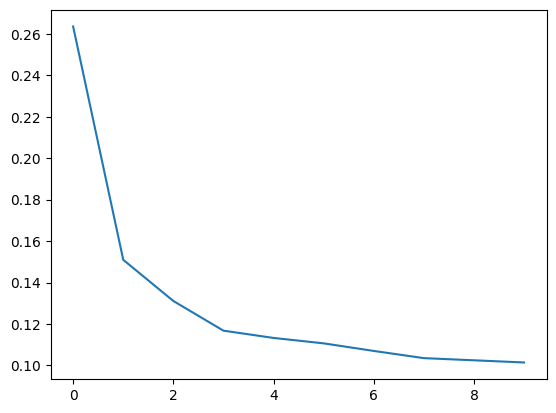

In [16]:
import pandas as pd

history_df = pd.DataFrame(history.history)
# usamos pandas nativos para hacer una grafica sencilla
history_df['loss'].plot()

Vemos que la funcion conforme se va hacercando al 0 en el eje y, quiere decir que va aprendiendo mejor.